In [ ]:
#Loading packages and Data
# import sys
# print(sys.path, "   \n\n\n", sys.executable)
# !jupyter kernelspec list

from IPython.display import Image
import numpy as np # linear algebray
import pandas as pd# data processing, CSV file I/O (e.g. pd.read_csv)
from pandas import read_csv
from pandas import DataFrame
from pandas import concat
from datetime import datetime
from random import random
from math import sqrt
from numpy import concatenate
from numpy import array
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import adfuller

from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal  import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
!pip install pmdarima
from pmdarima.arima import auto_arima
from prophet import Prophet


#!pip install plotly==3.10.0


#from plotly.plotly import plot_mpl


from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM


In [ ]:
data = pd.read_csv("2015.csv")
data.head()

,RTD End Time Stamp,Zone Name,Zone PTID,RTD Actual Load
0,2015/01/01 00:05:00,CAPITL,61757,1297.6
1,2015/01/01 00:10:00,CAPITL,61757,1301.2
2,2015/01/01 00:15:00,CAPITL,61757,1300.0
3,2015/01/01 00:20:00,CAPITL,61757,1292.3
4,2015/01/01 00:25:00,CAPITL,61757,1303.3


In [ ]:
data.rename(columns = {data.columns[0]: "time", data.columns[3]: "load"}, inplace = True)
data['time'] = pd.to_datetime(data["time"])
data.set_index("time", inplace = True)



In [ ]:
data.head()

,Zone Name,Zone PTID,load
time,,,
2015-01-01 00:05:00,CAPITL,61757,1297.6
2015-01-01 00:10:00,CAPITL,61757,1301.2
2015-01-01 00:15:00,CAPITL,61757,1300.0
2015-01-01 00:20:00,CAPITL,61757,1292.3
2015-01-01 00:25:00,CAPITL,61757,1303.3


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 106227 entries, 2015-01-01 00:05:00 to 2016-01-01 00:00:00
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Zone Name  106227 non-null  object 
 1   Zone PTID  106227 non-null  int64  
 2   load       106223 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 3.2+ MB


In [ ]:
# 4 nan values

data.loc[data["load"].isna() == True]

,Zone Name,Zone PTID,load
time,,,
2015-01-21 17:15:00,CAPITL,61757,NaN
2015-07-20 23:55:00,CAPITL,61757,NaN
2015-08-11 23:55:00,CAPITL,61757,NaN
2015-09-29 23:55:00,CAPITL,61757,NaN


In [ ]:
#filling nan values with previous load values
data = data.fillna(method = 'ffill')
#check if nan values are gone
timestamp = pd.Timestamp('2015-07-20 23:55:00')
selected_row = data.loc[timestamp]
print(selected_row)

Zone Name    CAPITL
Zone PTID     61757
load         1507.8
Name: 2015-07-20 23:55:00, dtype: object


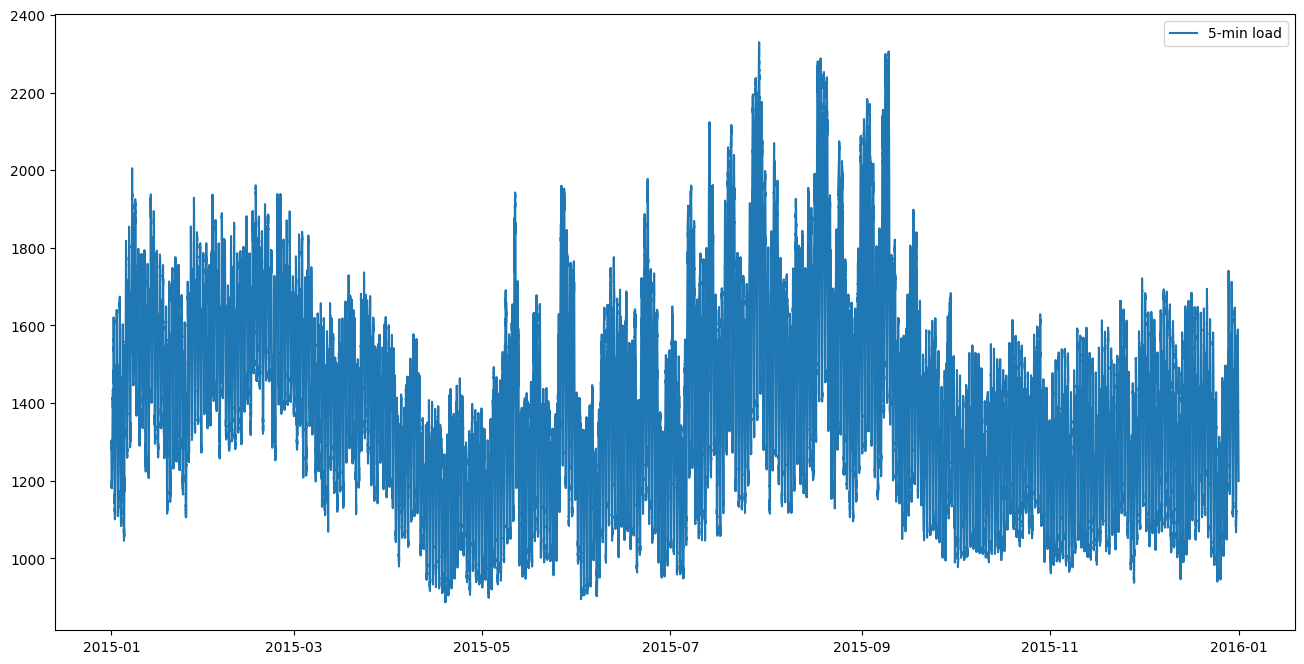

In [ ]:
plt.figure(figsize = (16, 8))
plt.plot(data["load"], label = "5-min load")
plt.legend()

In [ ]:
#drop some columns

remove_columns = ["Zone Name", "Zone PTID"]
for col in remove_columns:
    if col in data.columns:
        data = data.drop([col], axis = 1)
data.head()

,load
time,
2015-01-01 00:05:00,1297.6
2015-01-01 00:10:00,1301.2
2015-01-01 00:15:00,1300.0
2015-01-01 00:20:00,1292.3
2015-01-01 00:25:00,1303.3


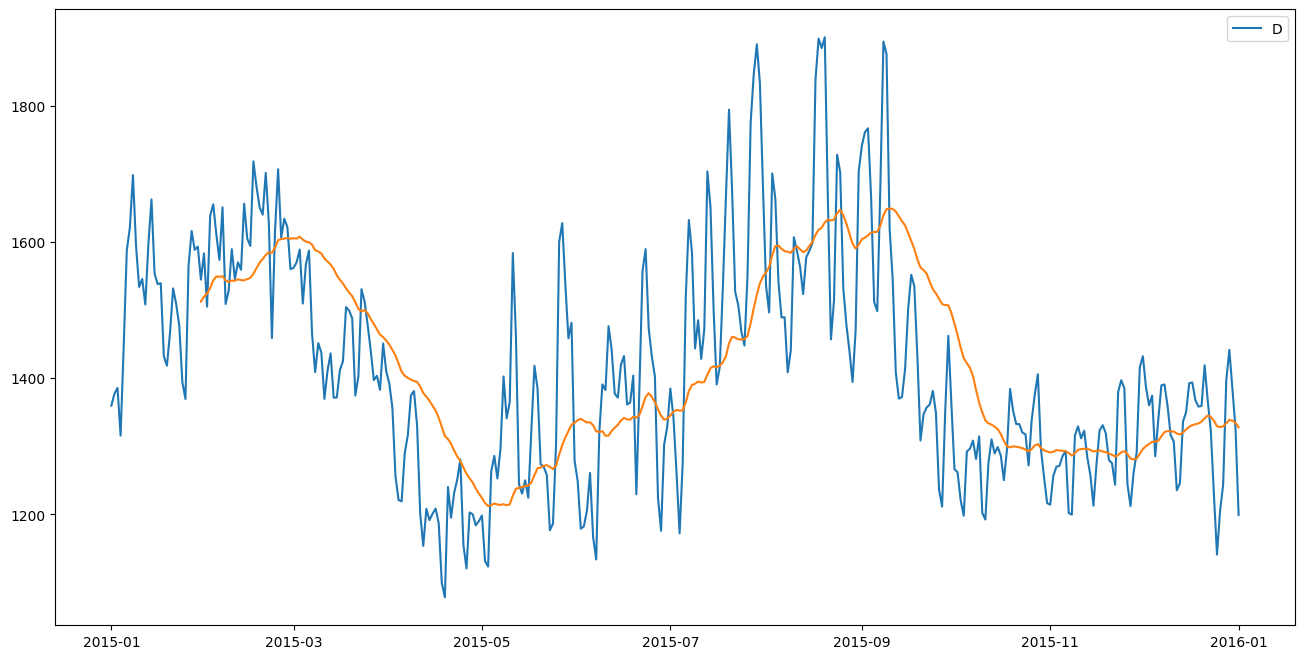

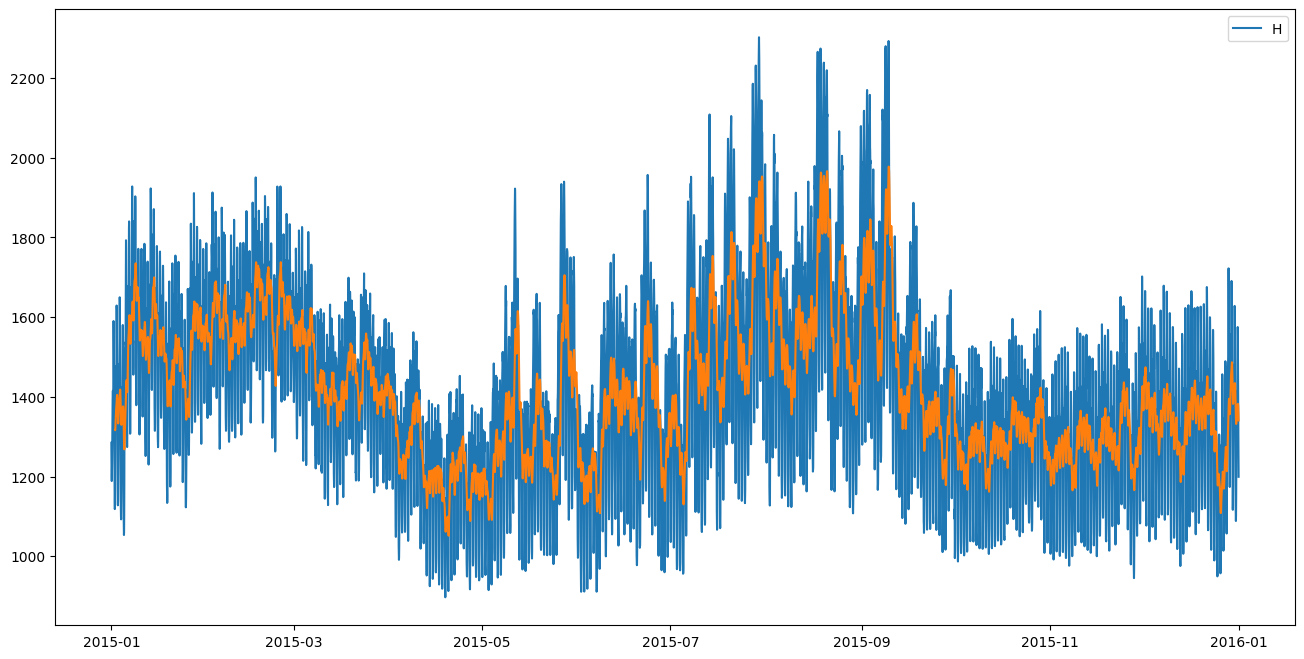

In [ ]:
#resample daily and hourly
def resample(data, mode):
    plt.figure(figsize = (16, 8))

    resampled = data.resample(mode).mean()
    resampled = resampled.fillna(method = "ffill")
    plt.plot(resampled, label = mode)
    plt.plot(resampled.rolling(30).mean())
    plt.legend()
    return resampled
dataD = resample(data, 'D')
dataH = resample(data, 'H')



In [ ]:
#create separate col for day, month, week, hour for each dataframe
def add_time_col(data):
    data.head()
    data["day"] = data.index.day
    data['month'] = data.index.month

    data['week']= data.index.isocalendar().week
    data['hour']= data.index.hour
    print(type(data.index.day),"type of month: ",type(data.index.month), "type of week: ",  type(data.index.isocalendar().week))
    print(data.head())

add_time_col(dataD)
add_time_col(dataH)
add_time_col(data)


<class 'pandas.core.indexes.numeric.Int64Index'> type of month:  <class 'pandas.core.indexes.numeric.Int64Index'> type of week:  <class 'pandas.core.series.Series'>
                   load  day  month  week  hour
time                                           
2015-01-01  1359.762718    1      1     1     0
2015-01-02  1377.112500    2      1     1     0
2015-01-03  1385.831849    3      1     1     0
2015-01-04  1315.892027    4      1     1     0
2015-01-05  1446.350342    5      1     2     0
<class 'pandas.core.indexes.numeric.Int64Index'> type of month:  <class 'pandas.core.indexes.numeric.Int64Index'> type of week:  <class 'pandas.core.series.Series'>
                            load  day  month  week  hour
time                                                    
2015-01-01 00:00:00  1284.645455    1      1     1     0
2015-01-01 01:00:00  1237.566667    1      1     1     1
2015-01-01 02:00:00  1200.808333    1      1     1     2
2015-01-01 03:00:00  1188.641667    1      1     

<IntegerArray>
[ 1,  1,  1,  1,  2,  2,  2,  2,  2,  2,
 ...
 52, 52, 52, 52, 52, 53, 53, 53, 53, 53]
Length: 366, dtype: UInt32


<Axes: xlabel='month', ylabel='load'>

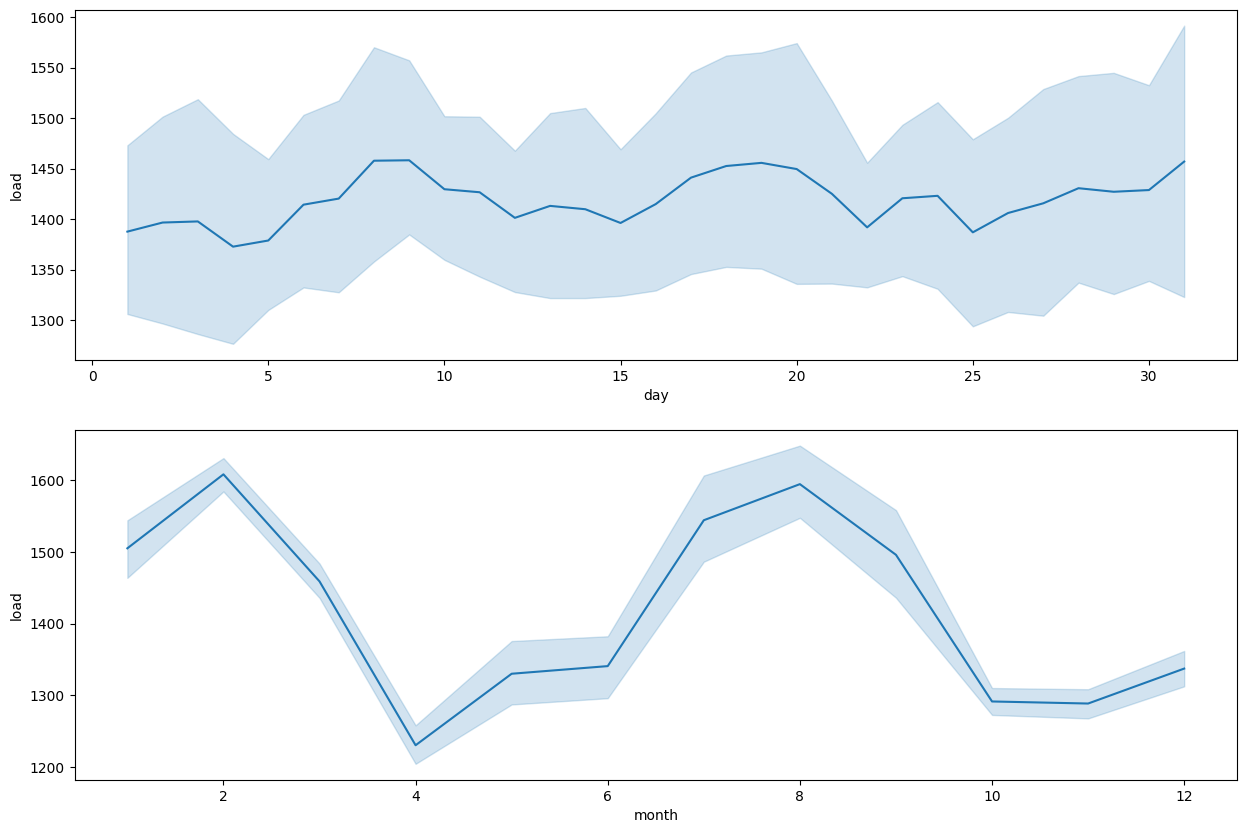

In [ ]:
week = dataD["week"].values
print(week)
fig, axes = plt.subplots(2, 1, figsize = (15, 10))
sns.lineplot(ax = axes[0], x = dataD["day"], y = dataD["load"])
sns.lineplot(ax = axes[1], x = dataD["month"], y = dataD["load"])
# sns.lineplot(ax = axes[2], x = week, y = dataD["load"])

P = 0.4387380711760954
data is non-stationary
P = 5.423326662374746e-09
data is stationary


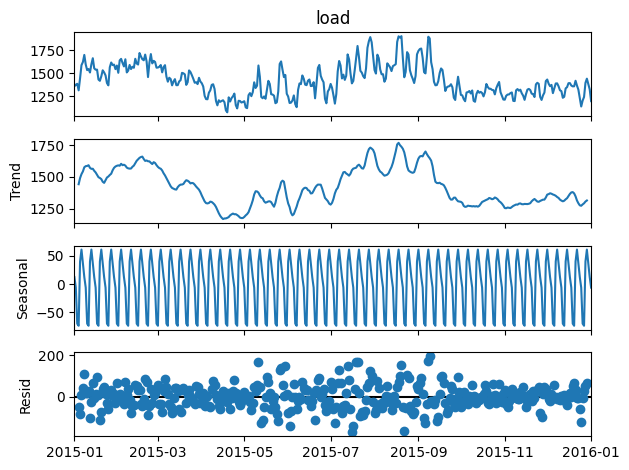

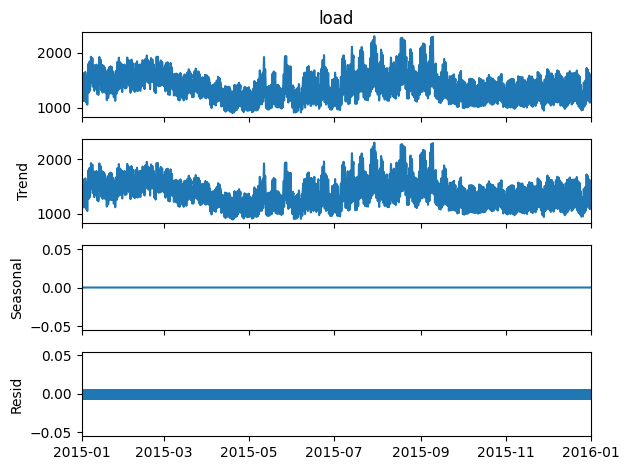

In [ ]:
#arima model
#decomposition and adfuller test
def arima_test(data_list, period, col):
    for i in range(len(data_list)):

        seasonal_decompose(data_list[i][col], period = period[i]).plot()

        fuller_test = adfuller(data_list[i][col])
        print(f'P = {fuller_test[1]}')
        if(fuller_test[1] <= 0.05):
            print("data is stationary")
        else:
            print("data is non-stationary")


arima_test([dataD, dataH], [ 7, 1], "load")





P = 1.516168508696494e-15
data is stationary


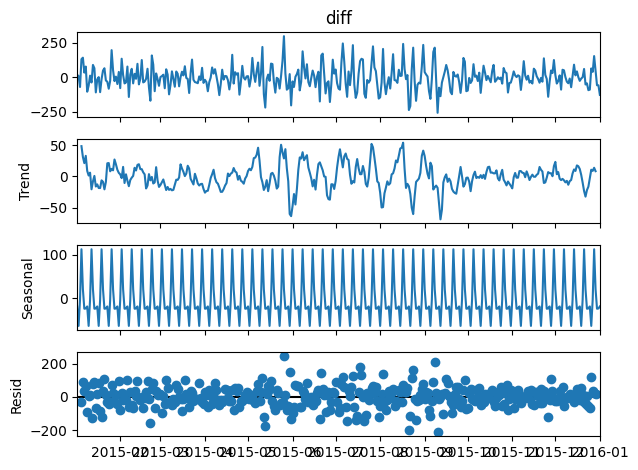

In [ ]:
#the above test suggests that the daily data is non-stationary whereas the hourly data is stationary
#let's work with daily data
dataD["diff"] = dataD["load"] - dataD["load"].shift(1)
dataD = dataD.dropna()
#check for arima test
arima_test([dataD], [ 7], "diff")
#check for seasonality



<Axes: xlabel='time'>

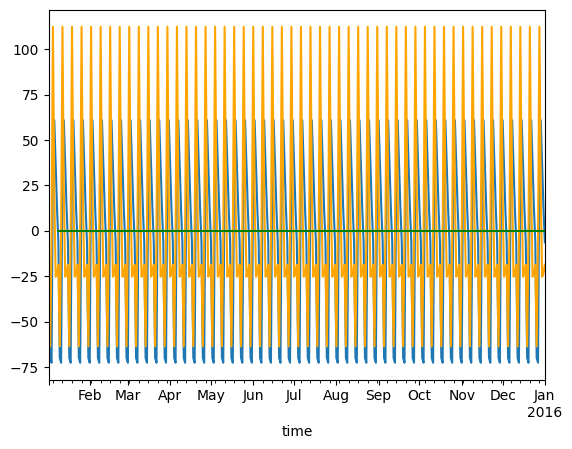

In [ ]:
seasonal=seasonal_decompose(dataD[['load']]).seasonal
#fig.ax=plt.subplots(figsize=(16,5))
seasonal.plot()
seasonal.diff(1).dropna().plot(color='orange')
seasonal.diff(7).dropna().plot(color='green')

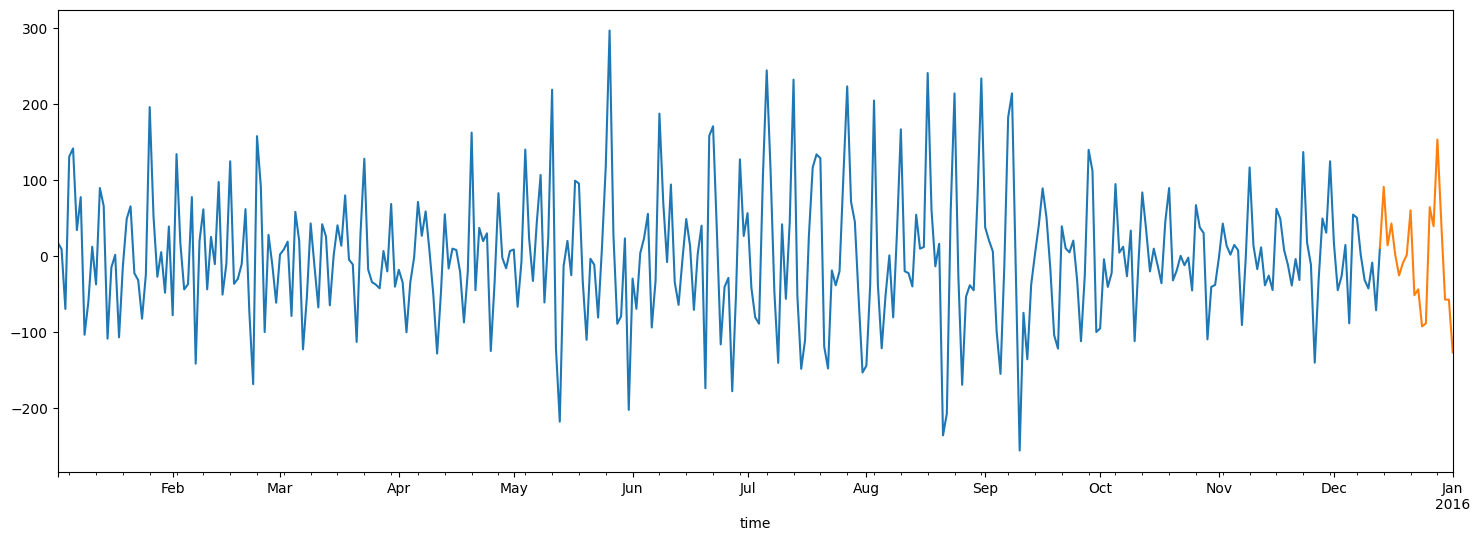

In [ ]:
#seasonality = 7

#divide the data into two

train = dataD.iloc[:346]
test = dataD.iloc[345:]

fig, ax = plt.subplots(figsize = (18,6))
train["diff"].plot(ax = ax)
test["diff"].plot(ax = ax)
plt.show()




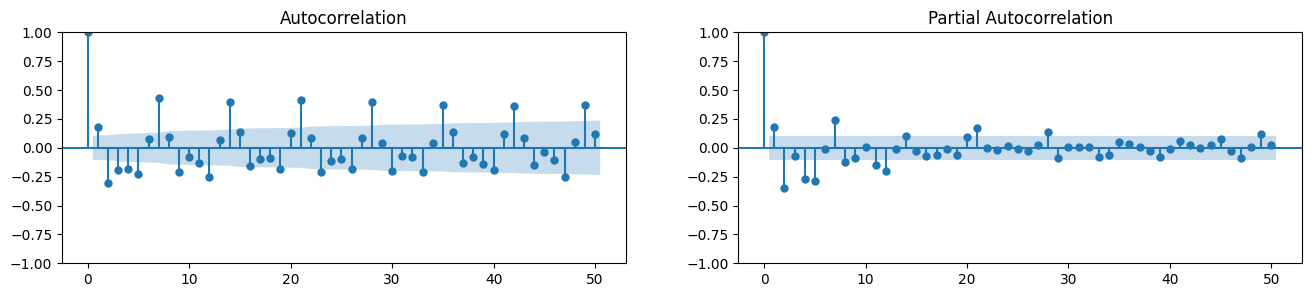

In [ ]:
#plot acf and pacf
fig, axes = plt.subplots(1,2,figsize=(16,3))
x=plot_acf(train["diff"], lags=50,ax=axes[0])
y=plot_pacf(train["diff"], lags=50, ax=axes[1])
plt.show()

In [ ]:
#gradual decreasing of acf: p = 1, d = 7, q = 2

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


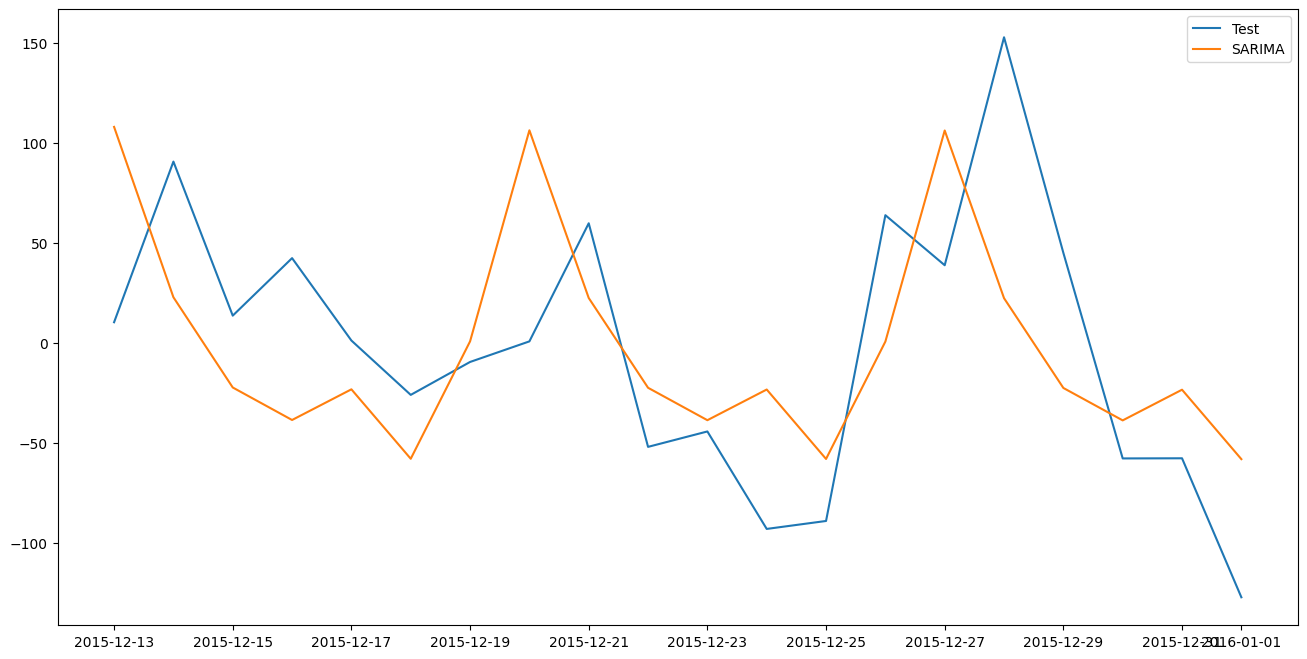

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
y_hat = test.copy()
fitArima = SARIMAX(train["diff"].values, order = (1, 1, 1), seasonal_order = (0, 1, 1, 7)).fit()

y_pred = fitArima.predict(dynamic = True)
y = fitArima.forecast(len(test), dynamic = True)
y_predicted = pd.DataFrame(y, index = y_hat.index, columns = ["sarima"])

plt.figure(figsize=(16,8))
plt.plot(test["diff"], label='Test')
plt.plot(y_predicted, label='SARIMA')
plt.legend(loc='best')
plt.show()

In [ ]:
rms = sqrt(mean_squared_error(test["diff"],y_predicted))
print(rms)


62.96117967566303


Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,1,1)[7]             : AIC=inf, Time=0.90 sec
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=4171.476, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[7]             : AIC=4066.466, Time=0.19 sec
 ARIMA(0,1,1)(0,1,1)[7]             : AIC=inf, Time=0.41 sec
 ARIMA(1,1,0)(0,1,0)[7]             : AIC=4141.131, Time=0.06 sec
 ARIMA(1,1,0)(2,1,0)[7]             : AIC=4029.798, Time=0.45 sec
 ARIMA(1,1,0)(2,1,1)[7]             : AIC=inf, Time=1.55 sec
 ARIMA(1,1,0)(1,1,1)[7]             : AIC=inf, Time=0.95 sec
 ARIMA(0,1,0)(2,1,0)[7]             : AIC=4063.827, Time=0.98 sec
 ARIMA(2,1,0)(2,1,0)[7]             : AIC=3990.609, Time=1.79 sec
 ARIMA(2,1,0)(1,1,0)[7]             : AIC=4027.216, Time=1.18 sec
 ARIMA(2,1,0)(2,1,1)[7]             : AIC=inf, Time=3.50 sec
 ARIMA(2,1,0)(1,1,1)[7]             : AIC=inf, Time=1.39 sec
 ARIMA(3,1,0)(2,1,0)[7]             : AIC=3973.468, Time=1.50 sec
 ARIMA(3,1,0)(1,1,0)[7]             : AIC=4011.722, Time=0.97 s

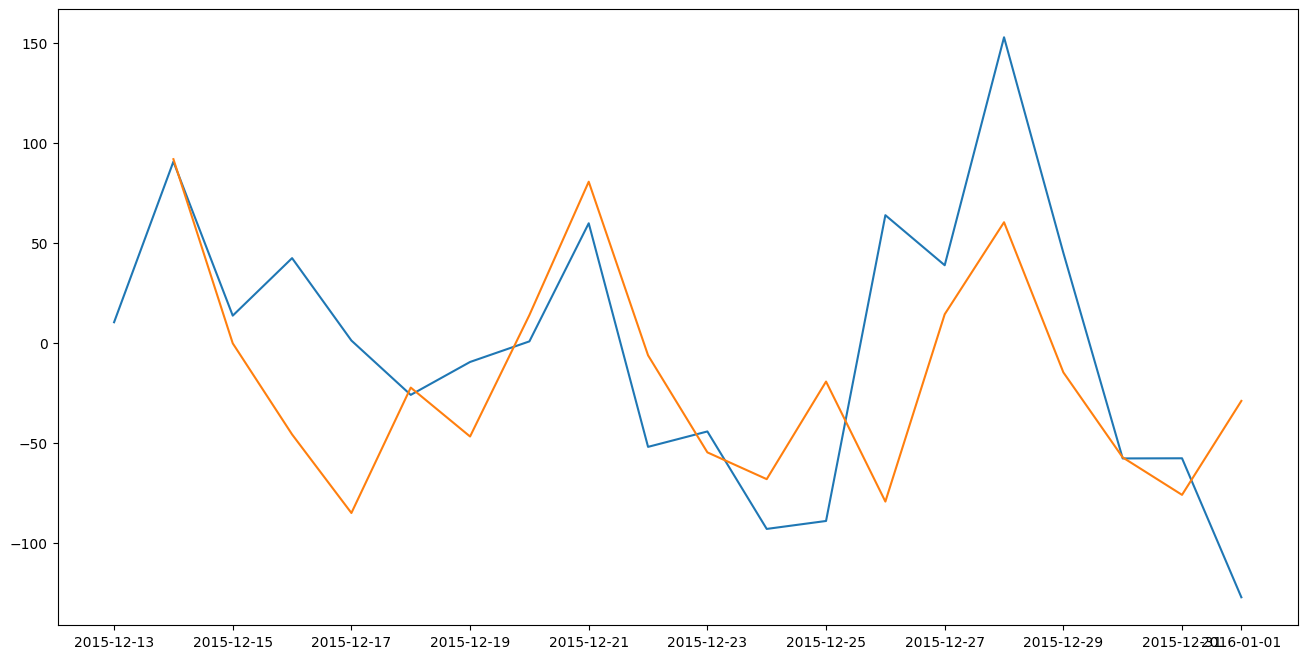

In [ ]:
#auto arima
#building the model
model = auto_arima(train["diff"],start_p=1,d=1,start_q=1,max_p=3,max_d=2,max_q=3,start_P=1,D=1,start_Q=1,
                   max_P=2,max_D=1,max_Q=2,seasonal =True, m=7, max_order=5,stationary=False, trace=True, error_action='ignore', suppress_warnings=True)
model.fit(train["diff"])

forecast = model.predict(n_periods=len(test["diff"]))
forecast = pd.DataFrame(forecast,index = test.index,columns=['Prediction'])

#plot the predictions for validation set
plt.figure(figsize=(16,8))
plt.plot(test["diff"], label='Valid')
plt.plot(forecast, label='Prediction')
plt.show()

In [ ]:

forecast = forecast.fillna(method = 'bfill')

rms = sqrt(mean_squared_error(test["diff"],forecast))
print(rms)


61.17565670939014


In [ ]:
#lstm

In [ ]:
def split_sequence(sequence, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the sequence
        if out_end_ix > len(sequence):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix:out_end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [ ]:
# define input sequence
raw_seq = train["diff"].values.tolist()
# choose a number of time steps
n_steps_in, n_steps_out = 30, 20
# split into samples
X, y = split_sequence(raw_seq, n_steps_in, n_steps_out)
# reshape from [samples, timesteps] into [samples, timesteps, features]
n_features = 1
X = X.reshape((X.shape[0], X.shape[1], n_features))

# define model

NameError: name 'train' is not defined

In [ ]:
#LSTM model
model = Sequential()
model.add(LSTM(100, activation='relu', return_sequences=True, input_shape=(n_steps_in, n_features)))
model.add(LSTM(100, activation='relu'))
model.add(Dense(n_steps_out))
model.compile(optimizer='adam', loss='mse')
# fit model
model.fit(X, y, epochs=50, verbose=0)

In [ ]:

x_input = train["diff"][-n_steps_in:].values

x_input = x_input.reshape((1, n_steps_in, n_features))
yhat = model.predict(x_input, verbose=0)
print(yhat)

[[ 2.2862315   4.1154995  -0.4292249  -3.4401252  -3.3868852   0.7362146
   3.99115     1.0392374  -0.49075332 -5.2153687  -3.9694297  -0.63604885
   2.4821982  -1.6123557   0.9304273   2.270698    0.9126405   0.19819106
  -2.2066724  -2.5417473 ]]


In [ ]:
yhat=yhat.reshape(20,1)

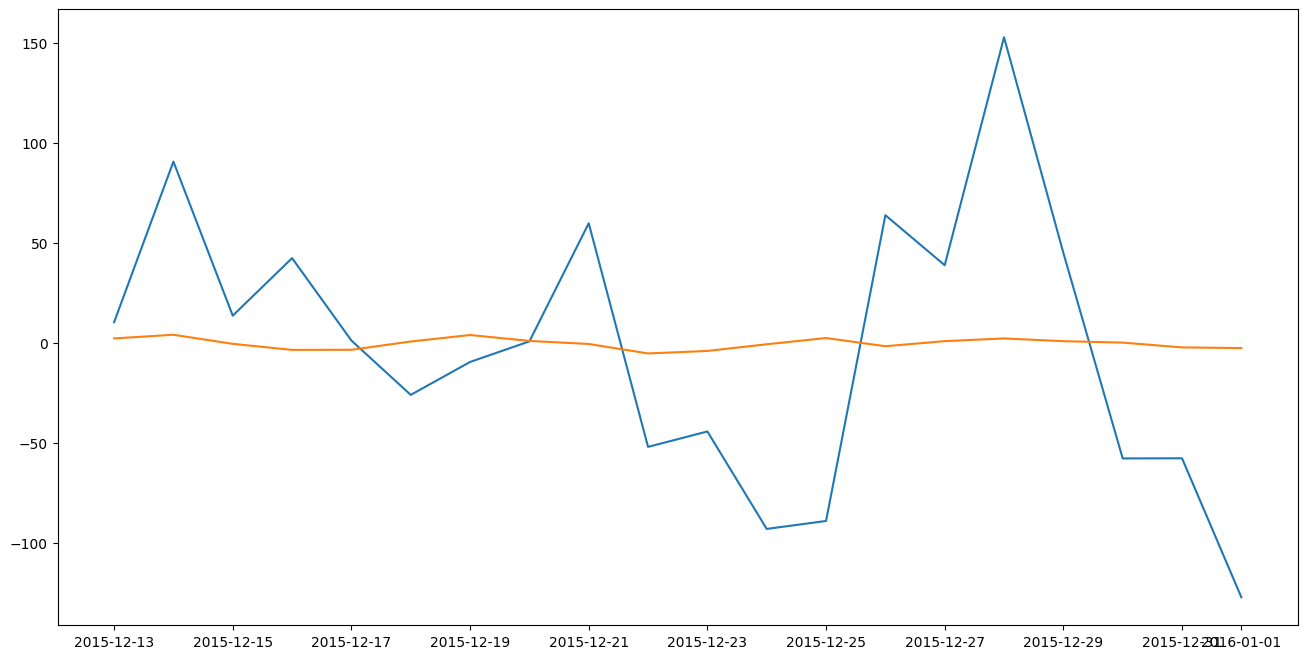

            Prediction
time                  
2015-12-13    2.286232
2015-12-14    4.115499
2015-12-15   -0.429225
2015-12-16   -3.440125
2015-12-17   -3.386885


In [ ]:
forecast = pd.DataFrame(yhat,index = test.index,columns=['Prediction'])

#plot the predictions for validation set
plt.figure(figsize=(16,8))
plt.plot(test["diff"], label='Valid')
plt.plot(forecast, label='Prediction')
plt.show()
print(forecast.head())

In [ ]:
rms = sqrt(mean_squared_error(test["diff"],forecast))
print(rms)

66.07564843920215
